<a href="https://colab.research.google.com/github/IGol22/SFML/blob/main/%D0%9A%D1%83%D1%80%D1%81%D0%BE%D0%B2%D0%B0%D1%8F/%D0%A0%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D1%8FIC50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

import os

file_name = "dataset_classic_ML.xlsx"


if not os.path.exists(file_name):
    raw_url = "https://raw.githubusercontent.com/IGol22/SFML/main/Курсовая/dataset_classic_ML.xlsx"
    !wget -q -O {file_name} "{raw_url}"

df = pd.read_excel(file_name)
df = df.drop(columns=["Unnamed: 0"], errors="ignore")
df.head()


,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,31.000104,34.999650,1.129017,12.934891,12.934891,0.048029,-0.476142,0.382752,49.133333,414.542,...,0,0,0,0,0,0,0,0,0,0
997,31.999934,33.999415,1.062484,13.635345,13.635345,0.030329,-0.699355,0.369425,44.542857,485.621,...,0,0,0,0,0,0,0,0,0,0
998,30.999883,33.999458,1.096761,13.991690,13.991690,0.026535,-0.650790,0.284923,41.973684,545.742,...,1,0,0,0,0,0,0,0,0,0
999,31.998959,32.999644,1.031272,13.830180,13.830180,0.146522,-1.408652,0.381559,39.000000,522.635,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
target_col = 'IC50, mM'
targets_to_drop = ['IC50, mM', 'CC50, mM', 'SI']
X = df.drop(columns=targets_to_drop, errors='ignore')
y = df[target_col]


if X.isnull().sum().sum() > 0:
        X = X.fillna(X.median())


selector = VarianceThreshold(threshold=0.01)
X_reduced_array = selector.fit_transform(X)
X_columns = X.columns[selector.get_support()]


X_reduced = pd.DataFrame(X_reduced_array, columns=X_columns)


X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)

print("Размеры выборок:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Размеры выборок:
X_train: (800, 176)
X_test: (201, 176)
y_train: (800,)
y_test: (201,)


In [ ]:
# Переводим таргет в логарифмическую шкалу (pIC50)
# Добавляем 1e-9 (микро-число), чтобы не взять логарифм от нуля, если он есть
y_train_log = -np.log10(y_train + 1e-9)
y_test_log = -np.log10(y_test + 1e-9)


def get_models_and_params():
    """Сетка параметров для работы в Colab."""
    return {
        "Ridge Regression": (
            Pipeline(
                [
                    ("scaler", StandardScaler()),
                    ("model", Ridge(random_state=42)),
                ]
            ),
            {"model__alpha": [0.1, 1.0, 10.0, 100.0]},
        ),
        "Random Forest": (
            Pipeline(
                [
                    ("scaler", StandardScaler()),
                    (
                        "model",
                        RandomForestRegressor(
                            random_state=42
                        ),
                    ),
                ]
            ),
            {
                "model__n_estimators": [100],  # 100 деревьев — золотой стандарт
                "model__max_depth": [10, 20, None],
                "model__min_samples_split": [2, 5],
            },
        ),
        "Gradient Boosting": (
            Pipeline(
                [
                    ("scaler", StandardScaler()),
                    ("model", GradientBoostingRegressor(random_state=42)),
                ]
            ),
            {
                "model__n_estimators": [100],
                "model__learning_rate": [0.05, 0.1],
                "model__max_depth": [3, 5],
            },
        ),
        "Support Vector Regressor (SVR)": (
            Pipeline([("scaler", StandardScaler()), ("model", SVR())]),
            {
                "model__C": [0.1, 1.0, 10.0],
                "model__epsilon": [0.1],
                "model__kernel": ["rbf"],
            },
        ),
        "K-Nearest Neighbors (KNN)": (
            Pipeline(
                [
                    ("scaler", StandardScaler()),
                    ("model", KNeighborsRegressor()),
                ]
            ),
            {
                "model__n_neighbors": [3, 5, 7, 9],
                "model__weights": ["uniform", "distance"],
            },
        ),
    }

def evaluate_models(X_train, X_test, y_train, y_test):
    """Обучение, подбор гиперпараметров и оценка метрик."""
    models_params = get_models_and_params()
    results = []
    best_estimators = {}

    print("=" * 65)
    print("Обучение моделей И подбор гиперпараметров для pIC50")
    print("=" * 65)

    for name, (pipeline, params) in models_params.items():
        print(f"\n[Обучение] {name}...")

        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=params,
            cv=5,
            scoring="r2",
            n_jobs=2,
        )
        grid_search.fit(X_train, y_train)

        best_model = grid_search.best_estimator_
        best_estimators[name] = best_model

        # Прогноз
        y_pred = best_model.predict(X_test)

        # Расчет метрик
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        results.append(
            {
                "Модель": name,
                "R2 Score": r2,
                "MAE": mae,
                "RMSE": rmse,
                "Лучшие параметры": str(grid_search.best_params_),
            }
        )

        print(
            f"   -> R2 (Кросс-валидация): {grid_search.best_score_:.4f} | R2 (Тест): {r2:.4f}"
        )

    results_df = pd.DataFrame(results).sort_values(
        by="R2 Score", ascending=False
    )
    return results_df, best_estimators



Обучение моделей И подбор гиперпараметров для pIC50

[Обучение] Ridge Regression...
   -> R2 (Кросс-валидация): 0.0230 | R2 (Тест): 0.3508

[Обучение] Random Forest...
   -> R2 (Кросс-валидация): 0.4224 | R2 (Тест): 0.5097

[Обучение] Gradient Boosting...
   -> R2 (Кросс-валидация): 0.4134 | R2 (Тест): 0.4858

[Обучение] Support Vector Regressor (SVR)...
   -> R2 (Кросс-валидация): 0.3846 | R2 (Тест): 0.4315

[Обучение] K-Nearest Neighbors (KNN)...
   -> R2 (Кросс-валидация): 0.3457 | R2 (Тест): 0.4475

Итоговая таблица сравнения моделей для pIC50


,Модель,R2 Score,MAE,RMSE,Лучшие параметры
1,Random Forest,0.509677,0.544030,0.698919,"{'model__max_depth': 10, 'model__min_samples_s..."
2,Gradient Boosting,0.485754,0.554534,0.715766,"{'model__learning_rate': 0.1, 'model__max_dept..."
4,K-Nearest Neighbors (KNN),0.447502,0.573401,0.741910,"{'model__n_neighbors': 9, 'model__weights': 'u..."
3,Support Vector Regressor (SVR),0.431499,0.565739,0.752578,"{'model__C': 1.0, 'model__epsilon': 0.1, 'mode..."
0,Ridge Regression,0.350841,0.628517,0.804195,{'model__alpha': 10.0}


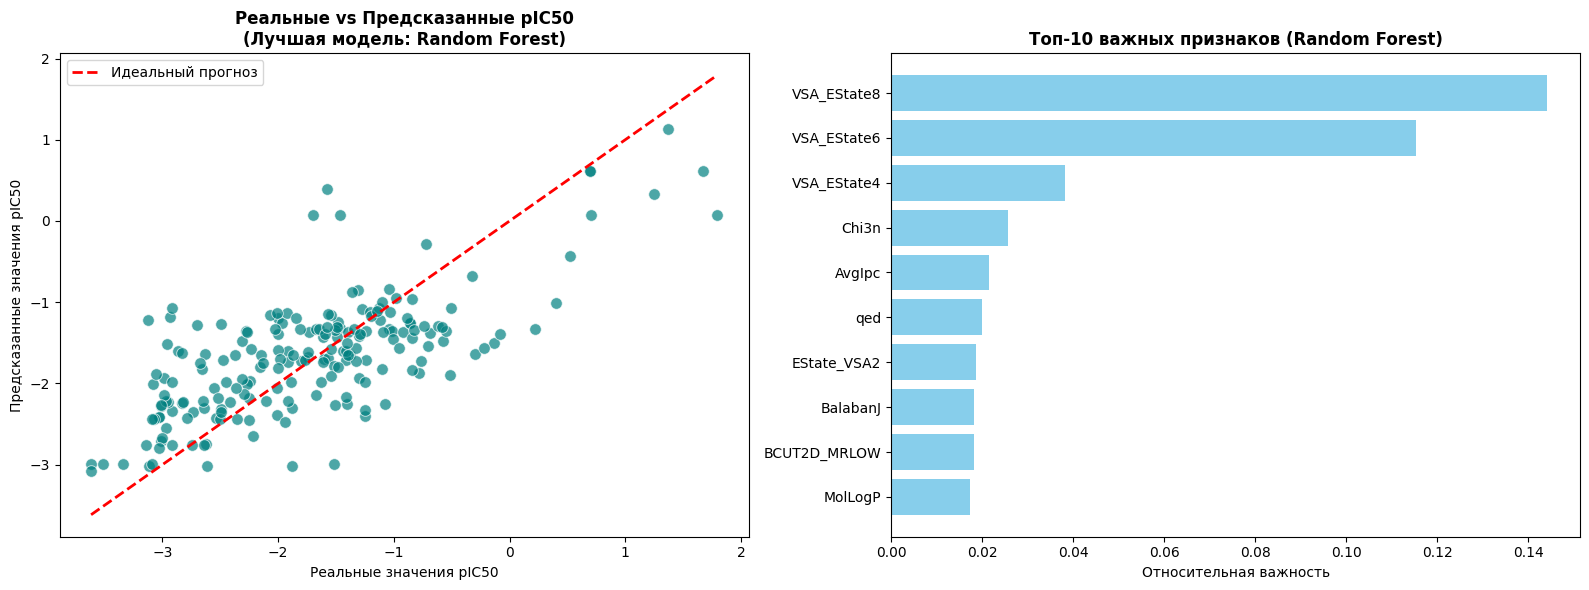

In [ ]:
# --- 1. Функция для отрисовки графиков ---
def plot_results(results_df, best_estimators, X_test, y_test_log, X_train):
    """Отрисовка результатов и важности признаков."""
    best_model_name = results_df.iloc[0]["Модель"]
    best_model = best_estimators[best_model_name]
    y_pred_best = best_model.predict(X_test)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # График 1: Реальные vs Предсказанные значения pIC50
    sns.scatterplot(
        x=y_test_log, y=y_pred_best, ax=axes[0], alpha=0.7, color="teal", s=70
    )
    axes[0].plot(
        [y_test_log.min(), y_test_log.max()],
        [y_test_log.min(), y_test_log.max()],
        "r--",
        lw=2,
        label="Идеальный прогноз",
    )
    axes[0].set_title(
        f"Реальные vs Предсказанные pIC50\n(Лучшая модель: {best_model_name})",
        fontsize=12,
        fontweight="bold",
    )
    axes[0].set_xlabel("Реальные значения pIC50")
    axes[0].set_ylabel("Предсказанные значения pIC50")
    axes[0].legend()

    # График 2: Топ-10 Важных признаков (если поддерживается) или сравнение R2
    model_obj = best_model.named_steps["model"]
    if hasattr(model_obj, "feature_importances_"):
        importances = model_obj.feature_importances_
        feature_names = X_train.columns
        top_indices = np.argsort(importances)[-10:]

        axes[1].barh(
            range(len(top_indices)),
            importances[top_indices],
            align="center",
            color="skyblue",
        )
        axes[1].set_yticks(range(len(top_indices)))
        axes[1].set_yticklabels([feature_names[i] for i in top_indices])
        axes[1].set_title(
            f"Топ-10 важных признаков ({best_model_name})",
            fontsize=12,
            fontweight="bold",
        )
        axes[1].set_xlabel("Относительная важность")
    else:
        sns.barplot(
            data=results_df,
            x="R2 Score",
            y="Модель",
            ax=axes[1],
            palette="viridis",
        )
        axes[1].set_title(
            "Сравнение R2 Score всех моделей",
            fontsize=12,
            fontweight="bold",
        )

    plt.tight_layout()
    plt.show()


# --- 2. Запуск обучения и вывод результатов ---
# Передаем логарифмированный таргет
summary_df, best_models = evaluate_models(
    X_train, X_test, y_train_log, y_test_log
)

# Вывод таблицы
print("\n" + "=" * 65)
print("Итоговая таблица сравнения моделей для pIC50")
print("=" * 65)
display(summary_df[["Модель", "R2 Score", "MAE", "RMSE", "Лучшие параметры"]])

# Отрисовка графиков
plot_results(summary_df, best_models, X_test, y_test_log, X_train)

Выводы

1.Сравнение моделей

Лидер: Лучшие результаты показал Random Forest (R2 = 0.51, MAE = 0.54, RMSE = 0.70). С небольшим отставанием на втором месте идет Gradient Boosting (R2 = 0.49).

Нелинейность данных: Простая линейная регрессия (Ridge) выдала всего R2 = 0.35. Это подтверждает, что связь между строением молекулы и ее активностью сложная и нелинейная.

Подготовка таргета: Переход к логарифмической шкале (pIC50) стал ключевым шагом — без него из-за огромного разброса значений модели обучаться нормально не могут.

2.Анализ графиков

Реальные vs Предсказанные pIC50: Точки сгруппированы вдоль красной линии идеального прогноза. Модель одинаково адекватно оценивает как сильные, так и слабые соединения, без систематических перекосов.

Важность признаков: Главный вклад в предсказание вносят электротопологические индексы заряда (VSA_EState8, VSA_EState6, VSA_EState4), а также липофильность (MolLogP) и показатель лекарственноподобия (qed).

3.Ограничения и перспективы
Точность R2 около 0.51 — это нормальный физический потолок для табличных 2D-дескрипторов, так как они не учитывают объемную (3D) форму молекулы в пространстве и погрешность мокрого лабораторного эксперимента. Для дальнейшего улучшения модели стоит попробовать 3D-дескрипторы или графовые нейросети (GNN).